## Import thư viện

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

## Đọc dữ liệu

In [5]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")

# Xóa missing
df = df.dropna()

# Xử lý datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['date'] = df['order_purchase_timestamp'].dt.date

# Gom theo ngày
df_prophet = df.groupby('date')['payment_value'].sum().reset_index()
df_prophet.columns = ['ds','y']

df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet = df_prophet.sort_values('ds')

In [6]:
## TRAIN / TEST SPLIT

In [7]:
test_days = 30

train = df_prophet.iloc[:-test_days]
test = df_prophet.iloc[-test_days:]

In [8]:
## TRAIN MODEL (EVALUATION MODEL)

In [9]:
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

# Nếu dataset là Brazil (Olist)
model.add_country_holidays(country_name='BR')

model.fit(train)

23:27:08 - cmdstanpy - INFO - Chain [1] start processing
23:27:08 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
## PREDICT TEST

In [11]:
future = model.make_future_dataframe(periods=test_days)

forecast = model.predict(future)

forecast_test = forecast.tail(test_days)

y_pred = forecast_test['yhat'].values
y_true = test['y'].values

In [12]:
## EVALUATION

In [13]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("=== PROPHET EVALUATION ===")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,4))

=== PROPHET EVALUATION ===
MAE: 11607.09
RMSE: 14190.19
R2: -0.0623


In [14]:
## VISUALIZE TEST

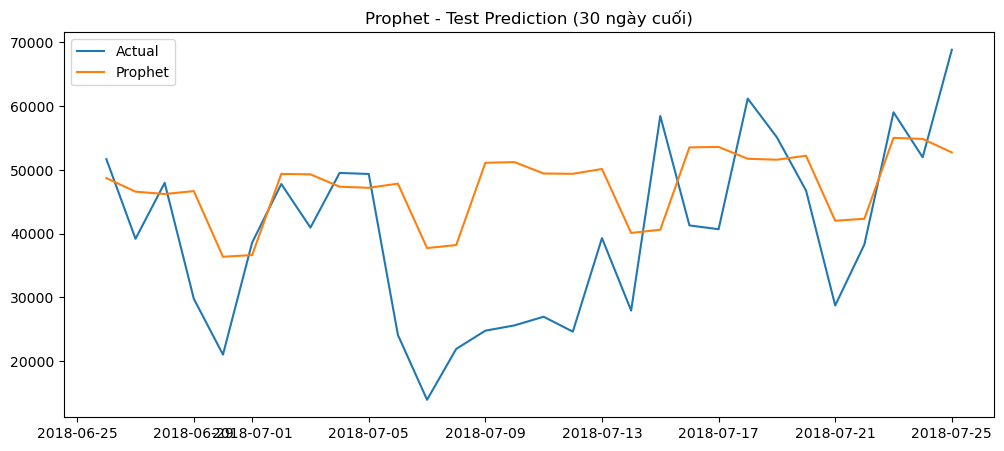

In [15]:
plt.figure(figsize=(12,5))

plt.plot(test['ds'], y_true, label='Actual')
plt.plot(test['ds'], y_pred, label='Prophet')

plt.legend()
plt.title("Prophet - Test Prediction (30 ngày cuối)")
plt.show()

In [16]:
## TRAIN FULL MODEL

In [17]:
final_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

final_model.add_country_holidays(country_name='BR')

final_model.fit(df_prophet)

23:27:09 - cmdstanpy - INFO - Chain [1] start processing
23:27:09 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
## FORECAST 30 NGÀY

In [19]:
future_full = final_model.make_future_dataframe(periods=30)

forecast_full = final_model.predict(future_full)

future_30 = forecast_full[['ds','yhat','yhat_lower','yhat_upper']].tail(30)

print("📈 DỰ ĐOÁN 30 NGÀY TỚI:")
print(future_30)

📈 DỰ ĐOÁN 30 NGÀY TỚI:
            ds          yhat    yhat_lower    yhat_upper
576 2018-07-26  50206.664718  33405.275523  66029.422330
577 2018-07-27  50271.590042  33108.990752  66477.952545
578 2018-07-28  39880.039412  23673.748672  55096.917377
579 2018-07-29  40844.224876  24145.139374  57383.660228
580 2018-07-30  52952.726882  36271.506555  68443.402866
581 2018-07-31  52424.331261  36168.780864  68829.423165
582 2018-08-01  50637.661974  34634.833654  67090.367268
583 2018-08-02  49779.165287  33404.534519  65621.416596
584 2018-08-03  49359.770397  33841.300179  65455.471336
585 2018-08-04  38529.663739  23296.189211  54634.822955
586 2018-08-05  39111.287511  23251.482447  55742.289572
587 2018-08-06  50902.063873  34350.325286  67364.671718
588 2018-08-07  50128.008727  33699.621704  66880.907741
589 2018-08-08  48173.180220  31016.511565  63906.158050
590 2018-08-09  47227.522571  31464.235262  63080.671626
591 2018-08-10  46803.434137  30993.131113  62142.937339
592 2018

In [20]:
## VISUALIZE FUTURE

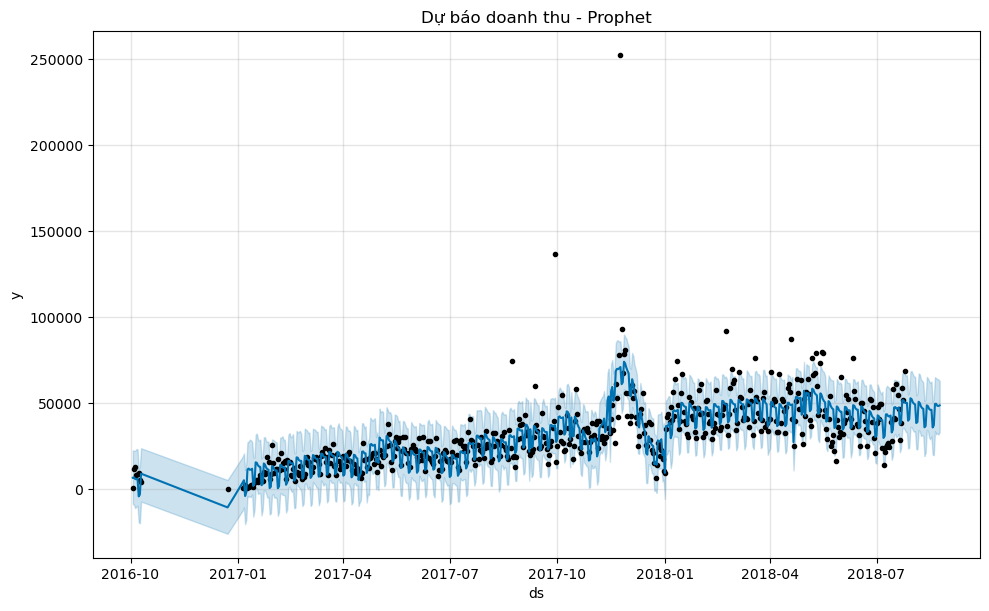

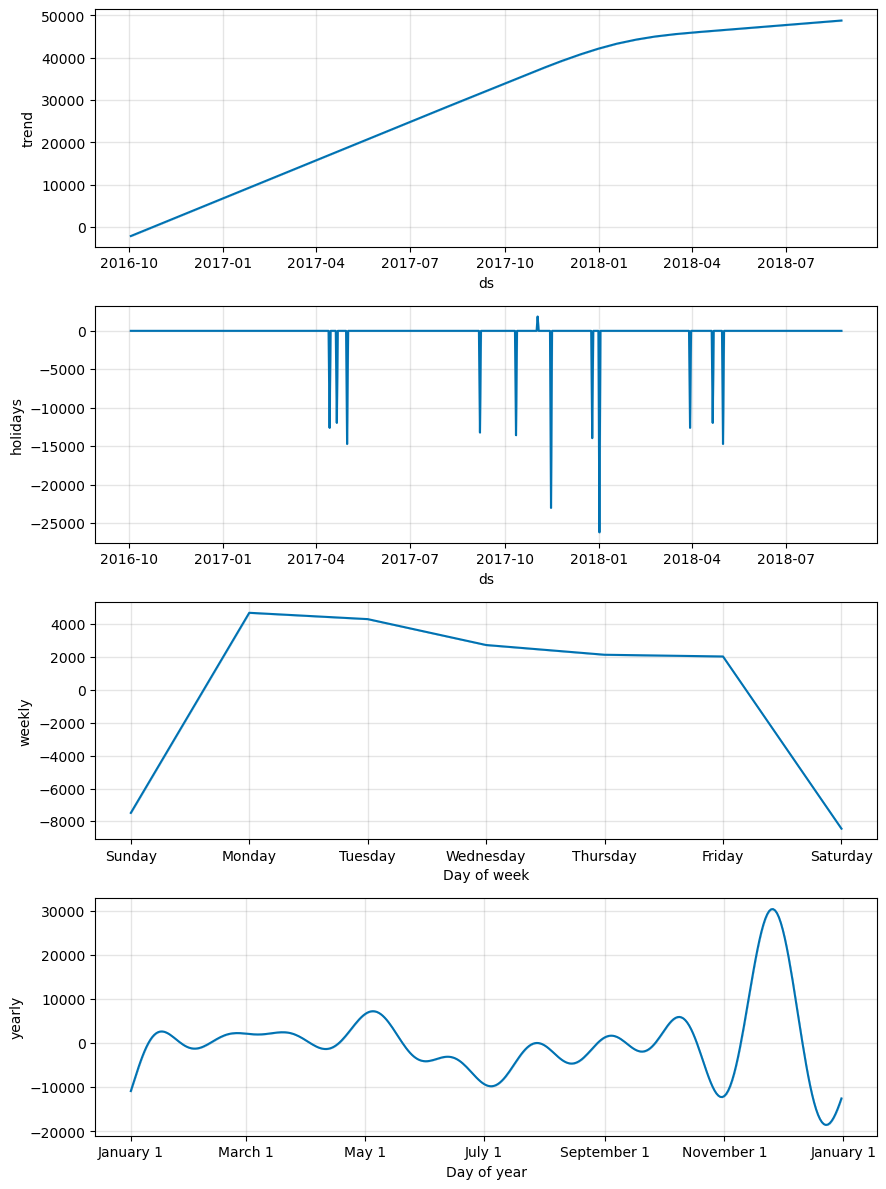

In [21]:
final_model.plot(forecast_full)
plt.title("Dự báo doanh thu - Prophet")
plt.show()

final_model.plot_components(forecast_full)
plt.show()

In [22]:
## SAVE MODEL

In [23]:
# =========================
# 1. MODEL EVALUATION
# =========================
with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

# =========================
# 2. MODEL PRODUCTION
# =========================
with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model_prod.pkl", "wb") as f:
    pickle.dump(final_model, f)

In [24]:
## LOAD MODEL

In [25]:
# Load model production
model_loaded = pickle.load(open(
    r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl", "rb"
))